## RAW DATA PROCESSING AND MERGING

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
index_csv_file='../data/raw/index.csv'
index_df=pd.read_csv(index_csv_file,index_col=False)

surface_csv_file='../data/raw/surface.csv'
surface_df=pd.read_csv(surface_csv_file,index_col=False)

In [31]:
index_df

,YEAR,MONTH,DAY,SWEAT index,Showalter index,LIFTED index,K index,Cross totals index,Vertical totals index,Totals totals index,TLCL,PLCL,CINE,CAPE,PRECIPITABLE WATER,1000-500 THICKNESS
0,1981,1,1,91.2,12.4,13.4,-1.4,3.0,21.7,24.7,284.41,993.98,0.0,0.0,22.8,5636
1,1981,1,2,75.7,10.2,11.3,1.6,10.2,20.1,30.3,282.11,956.13,0.0,0.0,20.4,5592
2,1981,1,4,128.3,6.9,6.9,17.5,16.3,25.3,41.6,284.79,978.71,0.0,0.0,23.8,5581
3,1981,1,5,194.2,2.8,1.2,23.5,22.5,28.1,50.6,286.68,965.77,-138.5,83.1,28.6,5578
4,1981,1,6,151.4,5.1,1.8,25.4,18.9,24.9,43.8,289.11,975.72,-112.9,47.9,33.2,5648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11878,2020,12,27,75.7,17.1,17.2,-19.9,-24.3,21.8,-2.5,279.17,876.91,0.0,0.0,9.5,5731
11879,2020,12,28,67.9,15.9,15.5,-6.5,-21.5,20.4,-1.1,280.77,893.60,0.0,0.0,11.4,5718
11880,2020,12,29,98.9,16.2,16.1,-15.2,5.3,18.1,23.4,278.86,862.08,0.0,0.0,13.4,5717
11881,2020,12,30,135.8,13.4,12.2,-6.5,11.4,18.1,29.5,282.07,892.90,0.0,0.0,16.2,5715


In [32]:
surface_df

,YEAR,MONTH,DAY,TH
0,1981,1,1,0
1,1981,1,2,0
2,1981,1,3,0
3,1981,1,4,0
4,1981,1,5,0
...,...,...,...,...
14392,2020,12,27,0
14393,2020,12,28,0
14394,2020,12,29,0
14395,2020,12,30,0


count the number of TH 

In [33]:
th_counts=surface_df['TH'].value_counts()
print(th_counts)

TH
0    11624
1     2772
         1
Name: count, dtype: int64


### MERGING

In [34]:
index_df.describe()

,YEAR,MONTH,DAY,SWEAT index,Showalter index,LIFTED index,K index,Cross totals index,Vertical totals index,Totals totals index,TLCL,PLCL,CINE,CAPE,PRECIPITABLE WATER,1000-500 THICKNESS
count,11883.000000,11883.000000,11883.000000,11883.000000,11883.000000,11883.000000,11883.000000,11883.000000,11883.000000,11883.000000,11883.000000,11883.000000,11883.000000,11883.000000,11883.000000,11883.000000
mean,1998.286712,6.539510,15.728099,182.923858,6.931743,0.521754,23.206581,15.603484,24.329142,39.932626,292.705253,952.021543,-63.671472,900.712421,40.506825,5750.025162
std,11.154318,3.433968,8.819977,92.033776,4.465433,7.002176,15.823667,7.171165,4.109635,9.294096,6.189168,39.226386,404.003436,1332.376203,17.504832,70.235229
min,1981.000000,1.000000,1.000000,5.800000,-9.600000,-21.700000,-62.300000,-36.700000,8.900000,-17.900000,254.750000,497.250000,-29338.900000,0.000000,-24.400000,5530.000000
25%,1989.000000,4.000000,8.000000,104.600000,4.100000,-4.300000,11.400000,11.900000,21.700000,35.400000,288.035000,935.950000,-79.700000,0.000000,25.400000,5699.000000
50%,1997.000000,7.000000,16.000000,185.300000,6.600000,-1.400000,28.200000,17.700000,23.700000,41.800000,294.790000,961.010000,-12.900000,87.800000,38.600000,5757.000000
75%,2005.500000,10.000000,23.000000,249.050000,9.400000,4.600000,35.800000,20.700000,26.800000,45.800000,297.760000,979.870000,0.000000,1544.150000,55.400000,5806.000000
max,2020.000000,12.000000,31.000000,850.700000,44.100000,27.800000,62.100000,33.300000,40.700000,69.800000,310.810000,1168.110000,29.000000,16555.900000,98.900000,5961.000000


In [35]:
surface_df.describe()

,YEAR,MONTH,DAY
count,14397.000000,14397.000000,14397.000000
mean,2000.326179,6.517052,15.727026
std,11.426269,3.452945,8.800485
min,1981.000000,1.000000,1.000000
25%,1990.000000,4.000000,8.000000
50%,2000.000000,7.000000,16.000000
75%,2010.000000,10.000000,23.000000
max,2020.000000,12.000000,31.000000


convert all dats columns into date time format

In [36]:
index_df['Date']=pd.to_datetime(index_df[['YEAR','MONTH','DAY']]).dt.strftime('%d/%m/%y')
surface_df['Date']=pd.to_datetime(surface_df[['YEAR','MONTH','DAY']]).dt.strftime('%d/%m/%y')

In [37]:
surface_df

,YEAR,MONTH,DAY,TH,Date
0,1981,1,1,0,01/01/81
1,1981,1,2,0,02/01/81
2,1981,1,3,0,03/01/81
3,1981,1,4,0,04/01/81
4,1981,1,5,0,05/01/81
...,...,...,...,...,...
14392,2020,12,27,0,27/12/20
14393,2020,12,28,0,28/12/20
14394,2020,12,29,0,29/12/20
14395,2020,12,30,0,30/12/20


INNER JOIN

drop some cols

In [38]:
columns_to_drop=['DAY','MONTH','YEAR']
surface_df.drop(columns=columns_to_drop,inplace=True)
index_df.drop(columns=columns_to_drop,inplace=True)

merge

In [39]:
merged_df=pd.merge(index_df,surface_df,on='Date',how='inner')
merged_df.to_csv('../data/raw/merged_df_all12.csv',index=False)

## COMBINING DATA

In [40]:
merged_df=pd.read_csv('../data/raw/merged_df_all12.csv')
print(merged_df.head())

   SWEAT index  Showalter index  LIFTED index  K index  Cross totals index  \
0         91.2             12.4          13.4     -1.4                 3.0   
1         75.7             10.2          11.3      1.6                10.2   
2        128.3              6.9           6.9     17.5                16.3   
3        194.2              2.8           1.2     23.5                22.5   
4        151.4              5.1           1.8     25.4                18.9   

   Vertical totals index  Totals totals index    TLCL    PLCL   CINE  CAPE  \
0                   21.7                 24.7  284.41  993.98    0.0   0.0   
1                   20.1                 30.3  282.11  956.13    0.0   0.0   
2                   25.3                 41.6  284.79  978.71    0.0   0.0   
3                   28.1                 50.6  286.68  965.77 -138.5  83.1   
4                   24.9                 43.8  289.11  975.72 -112.9  47.9   

   PRECIPITABLE WATER  1000-500 THICKNESS      Date  TH  
0   

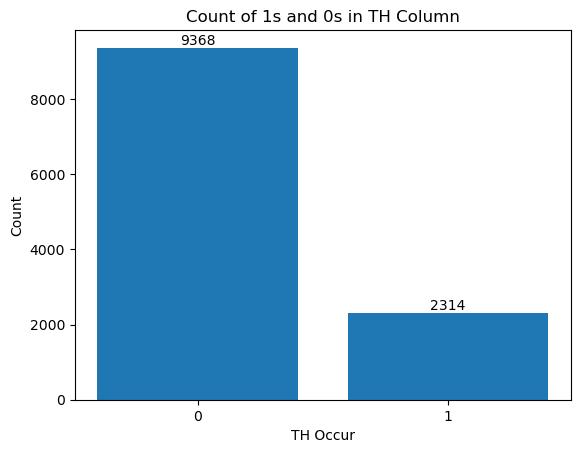

In [41]:
th_counts=merged_df['TH'].value_counts()
plt.bar(th_counts.index,th_counts.values)

plt.xlabel("TH Occur")
plt.ylabel("Count")
plt.title("Count of 1s and 0s in TH Column")

plt.xticks([0,1],['0','1'])

for i,count in enumerate(th_counts.values):
    plt.text(i,count,str(count),ha='center',va='bottom')

plt.show()

COMBINING

In [42]:
merged_df['Environmental_Stability']=merged_df['Showalter index']+merged_df['LIFTED index']
merged_df['Moisture_Indices']=merged_df['PRECIPITABLE WATER']
merged_df['Convective_Potential']=merged_df['CAPE']+merged_df['CINE']
merged_df['Temperature_Pressure']=merged_df['1000-500 THICKNESS']
merged_df['Moisture_Temperature_Profiles']=merged_df['PLCL']

In [43]:
merged_df.drop(['Showalter index','LIFTED index','PRECIPITABLE WATER','Cross totals index','Vertical totals index','CAPE','CINE','1000-500 THICKNESS','TLCL','PLCL'],axis=1,inplace=True)

In [44]:
merged_df

,SWEAT index,K index,Totals totals index,Date,TH,Environmental_Stability,Moisture_Indices,Convective_Potential,Temperature_Pressure,Moisture_Temperature_Profiles
0,91.2,-1.4,24.7,01/01/81,0,25.8,22.8,0.0,5636,993.98
1,75.7,1.6,30.3,02/01/81,0,21.5,20.4,0.0,5592,956.13
2,128.3,17.5,41.6,04/01/81,0,13.8,23.8,0.0,5581,978.71
3,194.2,23.5,50.6,05/01/81,0,4.0,28.6,-55.4,5578,965.77
4,151.4,25.4,43.8,06/01/81,0,6.9,33.2,-65.0,5648,975.72
...,...,...,...,...,...,...,...,...,...,...
11677,75.7,-19.9,-2.5,27/12/20,0,34.3,9.5,0.0,5731,876.91
11678,67.9,-6.5,-1.1,28/12/20,0,31.4,11.4,0.0,5718,893.60
11679,98.9,-15.2,23.4,29/12/20,0,32.3,13.4,0.0,5717,862.08
11680,135.8,-6.5,29.5,30/12/20,0,25.6,16.2,0.0,5715,892.90


Data is ready

In [45]:
columns=list(merged_df.columns)

columns.remove('TH')
columns.append('TH')

merged_df=merged_df[columns]

In [46]:
merged_df

,SWEAT index,K index,Totals totals index,Date,Environmental_Stability,Moisture_Indices,Convective_Potential,Temperature_Pressure,Moisture_Temperature_Profiles,TH
0,91.2,-1.4,24.7,01/01/81,25.8,22.8,0.0,5636,993.98,0
1,75.7,1.6,30.3,02/01/81,21.5,20.4,0.0,5592,956.13,0
2,128.3,17.5,41.6,04/01/81,13.8,23.8,0.0,5581,978.71,0
3,194.2,23.5,50.6,05/01/81,4.0,28.6,-55.4,5578,965.77,0
4,151.4,25.4,43.8,06/01/81,6.9,33.2,-65.0,5648,975.72,0
...,...,...,...,...,...,...,...,...,...,...
11677,75.7,-19.9,-2.5,27/12/20,34.3,9.5,0.0,5731,876.91,0
11678,67.9,-6.5,-1.1,28/12/20,31.4,11.4,0.0,5718,893.60,0
11679,98.9,-15.2,23.4,29/12/20,32.3,13.4,0.0,5717,862.08,0
11680,135.8,-6.5,29.5,30/12/20,25.6,16.2,0.0,5715,892.90,0


In [47]:
merged_df.to_csv('../data/processed/merged_df_all12k_combined.csv',index=False)

## MODEL TRAINING

import combined data

In [48]:
merge_df=pd.read_csv('../data/processed/merged_df_all12k_combined.csv')

print(merged_df.head())

   SWEAT index  K index  Totals totals index      Date  \
0         91.2     -1.4                 24.7  01/01/81   
1         75.7      1.6                 30.3  02/01/81   
2        128.3     17.5                 41.6  04/01/81   
3        194.2     23.5                 50.6  05/01/81   
4        151.4     25.4                 43.8  06/01/81   

   Environmental_Stability  Moisture_Indices  Convective_Potential  \
0                     25.8              22.8                   0.0   
1                     21.5              20.4                   0.0   
2                     13.8              23.8                   0.0   
3                      4.0              28.6                 -55.4   
4                      6.9              33.2                 -65.0   

   Temperature_Pressure  Moisture_Temperature_Profiles  TH  
0                  5636                         993.98   0  
1                  5592                         956.13   0  
2                  5581                        

In [49]:
merged_df=merged_df.drop(['Date'],axis=1)

In [52]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

x=merged_df[['SWEAT index', 'K index', 'Totals totals index', 'Environmental_Stability',
            'Moisture_Indices', 'Convective_Potential', 'Temperature_Pressure',
            'Moisture_Temperature_Profiles']]
y=merged_df['TH']

smote=SMOTE()
x_resampled,y_resampled=smote.fit_resample(x,y)

x_train,x_test,y_train,y_test=train_test_split(x_resampled,y_resampled,test_size=0.2,random_state=42)

model=RandomForestClassifier()

model.fit(x_train,y_train)

y_pred=model.predict(x_test)

HOW DID OUR MODEL PERFORM

In [58]:
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)

total_positive=cm[1].sum()
total_negative=cm[0].sum()
true_positives=cm[1][1]
false_positives=cm[0][1]
false_negatives=cm[1][0]
true_negatives=cm[0][0]

pod=true_positives/total_positive
far=false_positives/total_negative

hss=2 * ((true_positives * true_negatives) - (false_positives * false_negatives)) / (
        (true_positives + false_negatives) * (false_positives + true_negatives) +
        (true_positives + false_positives) * (false_negatives + true_negatives))
csi=true_positives/(true_positives+false_positives+false_negatives)

print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1-score:",f1)
print("="*40)
print("Probability of Detection (POD):",pod)
print("False Alarm Rate (FAR):",far)
print("Heidke Skill Score (HSS):",hss)
print("Critical Sucess Index (CSI):",csi)

Accuracy: 0.816435432230523
Precision: 0.767304189435337
Recall: 0.9049409237379162
F1-score: 0.830458353868901
Probability of Detection (POD): 0.9049409237379162
False Alarm Rate (FAR): 0.2709437963944857
Heidke Skill Score (HSS): 0.6434833677364087
Critical Sucess Index (CSI): 0.7100716392751791


PRINT CONFUSION MATRIX

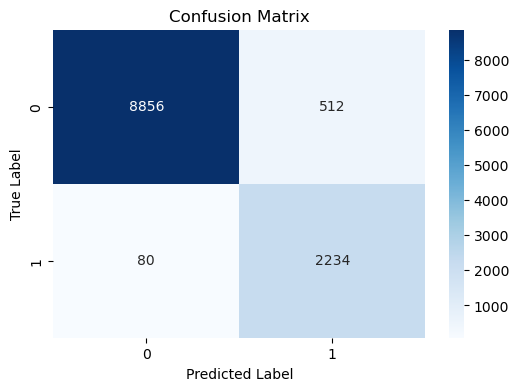

In [62]:
predictions=model.predict(x)

predictions=np.where(predictions.flatten()>0.6,1,0)

result_df=pd.DataFrame(data=x,columns=x.columns)
result_df['True Label']=y
result_df['Predicted Label']=predictions

true_labels=result_df['True Label']
predicted_labels=result_df['Predicted Label']

confusion_mat=confusion_matrix(true_labels,predicted_labels)
plt.figure(figsize=(6,4))
sns.heatmap(confusion_mat,annot=True,fmt='d',cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel('True Label')
plt.title("Confusion Matrix")

plt.show()